In [21]:
import h5py
import numpy as np
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pyl
import pywt
import pandas as pd

from cea.signal1D import*
from cea.general import*
from cea.output import*
from cea.data_loader import*

In [22]:
data, labels = load_RTCEA("data/RTCEA_bimode.hdf5")
atwood = create_atwood_dic(labels)

idxs = atwood[0.3]
sim = data[idxs,:,:] 
time = labels[idxs,1]

<!-- \newcommand{\ip}[2]{\langle #1, #2 \rangle} -->

# Comparaison des approches 1D

### Wavelet

La base des wavelets s'écrit comme
$$\quad B = \{ \psi_{j,n}\ ,\ (j,n)\in\mathbb{Z}^2 \ \ |\ \ \psi_{j,n} = \frac{1}{2^j}\psi^k( \frac{x-2^j n}{2^j} ) \}$$

**Wavelets linéaires**
$$f_J(x)=\sum_{ j \le J }\sum_{ j \le n } \langle f,\psi_{j,n}\rangle \psi_{j,n} \ ,\quad J=log_2(n)-1$$

**Wavelets non lineaires**
$$f_M(x)=\sum_{ (j,n) \in \Lambda_M } \langle f,\psi_{j,n} \rangle \psi_{j,n} \ , \quad \Lambda_M=\{c_{j,n}\ge M \ \ |\ \ c_{j,n}=\langle f,\phi_{j,n}\rangle\}$$

### Fourier

La base de fourier s'écrit comme
$$\quad F = \{ \phi_{k}\ ,\ k\in\mathbb{Z} \ \ |\ \ \phi_{k} = e^{2\pi ikx} \}$$

**TF Linéaire (basses fréquences**)
$$f_K(x)=\sum_{ |k| \le K }\langle f, \phi_k \rangle \phi_k$$

**TF non lineaires (fréquences dominantes)**
$$f_H(x)=\sum_{ k \in \Lambda_H } \langle f,\phi_m \rangle \phi_m \ , \quad \Lambda_H=\{c_k\ge H \ \ |\ \ c_k=\langle f, \phi_k \rangle \}$$

### ACP
$$X = U\Sigma V^T$$
avec $Cv_i = \lambda_i$ donc $V$ est la matrice des vecteurs propres de $C$ et $\Sigma$ celle des racines valeurs propres ($\Sigma = diag(\sqrt{\lambda_1}, \sqrt{\lambda_2}, ...)$). Enfin $U=X_c V \Sigma^{-1}$ la projection des données dans la nouvelle base.
D'ou $$f_a = V^T(f-\mu)$$

### Choix de l'erreur pour comparer la compression du signale

Choix naif norme L2


In [23]:
signals = sim[:,:,sim.shape[2]//2]
x = sim.shape[2]//2

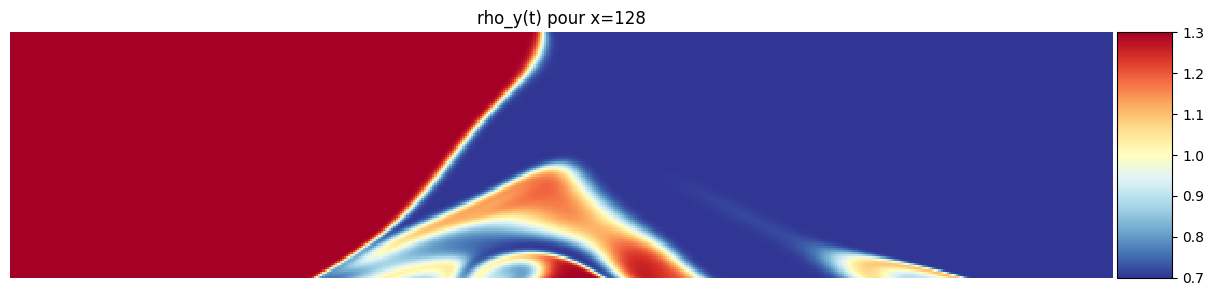

In [24]:
plt.figure(figsize=(15,15))
imageplot(signals, "rho_y(t) pour x=128",sbpt=[1,1,1], cmap='RdYlBu_r', colorbar=True)

## Calculs
### Parametres

In [25]:
T = 0.05
iteration = 50 #int(np.log2(n[0]))
wavelet = "sym6"
alpha = 0.2
t = signals.shape[0]-1

pACP = 90 #%
methods = [
    "Wavelets Lineaires",
    "Wavelets non Lineaires",
    "Fourier Lineaire",
    "Fourier non Lineaire",
    "ACP",
    "ACP " + str(pACP) + "%"
]

n = np.full(len(methods), int(signals[0,:].shape[0] /2)) # le n pour mes x méthode 
errors = np.zeros((len(methods), iteration, 2))

si = np.zeros((len(methods), signals.shape[1]))

### Bases d'ACP parametriques
Création de 2 bases d'ACP pour observer la capacité de generalisation de l'ACP au probleme.
- Base 100% : Créer a partir des resultat du temps complet de la simulation tel que $X = U\Sigma V^T | X=\{x_{l}(t) | t \in [0;t_{max}] \}$
- Base 95% : Créer a partir des resultat de 95% du temps de simulation tel que $X_{95} = U_{95}\Sigma_{95} V^T_{95} | X=\{x_{l}(t) | t \in [0;0.95\cdot t_{max}] \}$

In [26]:
base_acp = doACP(signals)
# s = int(0.95*signals.shape[0])
# sbase_acp = doACP(signals[:s])      # On fait l'ACP sur les premier 95% de la simulation pour regarder la generalisation

rng = np.random.default_rng(seed=42)  # seed pour reproductibilité
s_idx = rng.choice(signals.shape[0], size=int((pACP/100)*signals.shape[0]), replace=False)
sbase_acp = doACP(signals[s_idx])

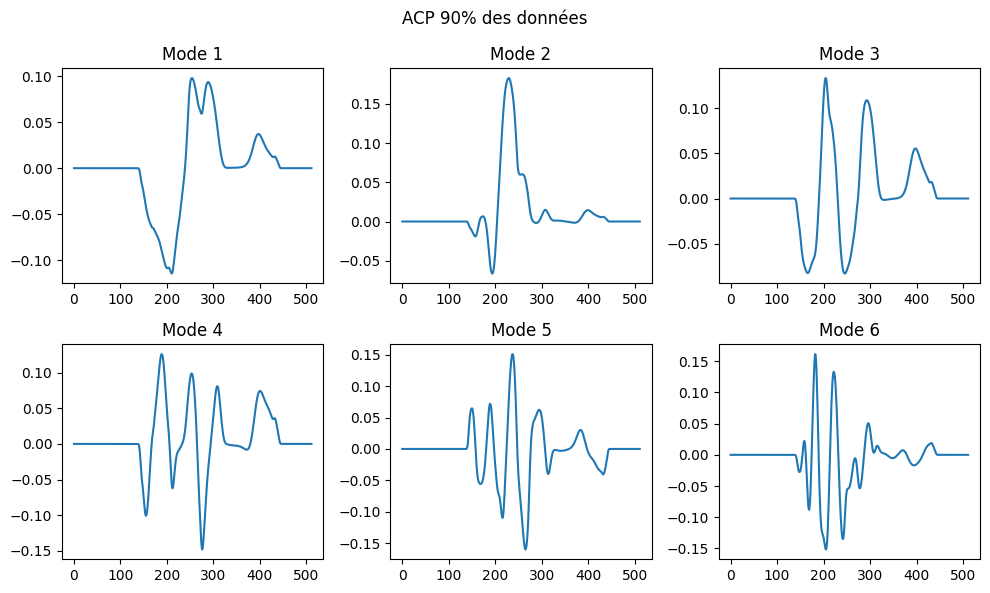

In [27]:
plot_acp_modes(sbase_acp, "ACP "+str(pACP)+"% des données")

### Boucle d'optimisation des vecteurs propres

In [28]:
for i in range(iteration):
    si[0,:] = wavelet_lineaire(signals[t],n[0],wavelet)
    si[1,:] = wavelet_non_lineaire(signals[t],n[1],wavelet)
    si[2,:] = fourier_lineaire(signals[t],n[2])
    si[3,:] = fourier_non_lineaire(signals[t],n[3])
    si[4,:] = acp_non_lineaire(base_acp, signals[t],n[4])
    si[5,:] = acp_non_lineaire(sbase_acp, signals[t],n[5])

    for j in range(len(methods)):
        err = np.linalg.norm(si[j] - signals[t])
        errors[j, i, 0] = n[j]
        errors[j, i, 1] = err
        
        if err < T:
            n[j] *= (1 - alpha)
        else:
            n[j] *= (1 + alpha)
            n[j] = max(1, min(len(signals[t]), int(n[j])))

print(n)

[289  76 409 409  26  26]


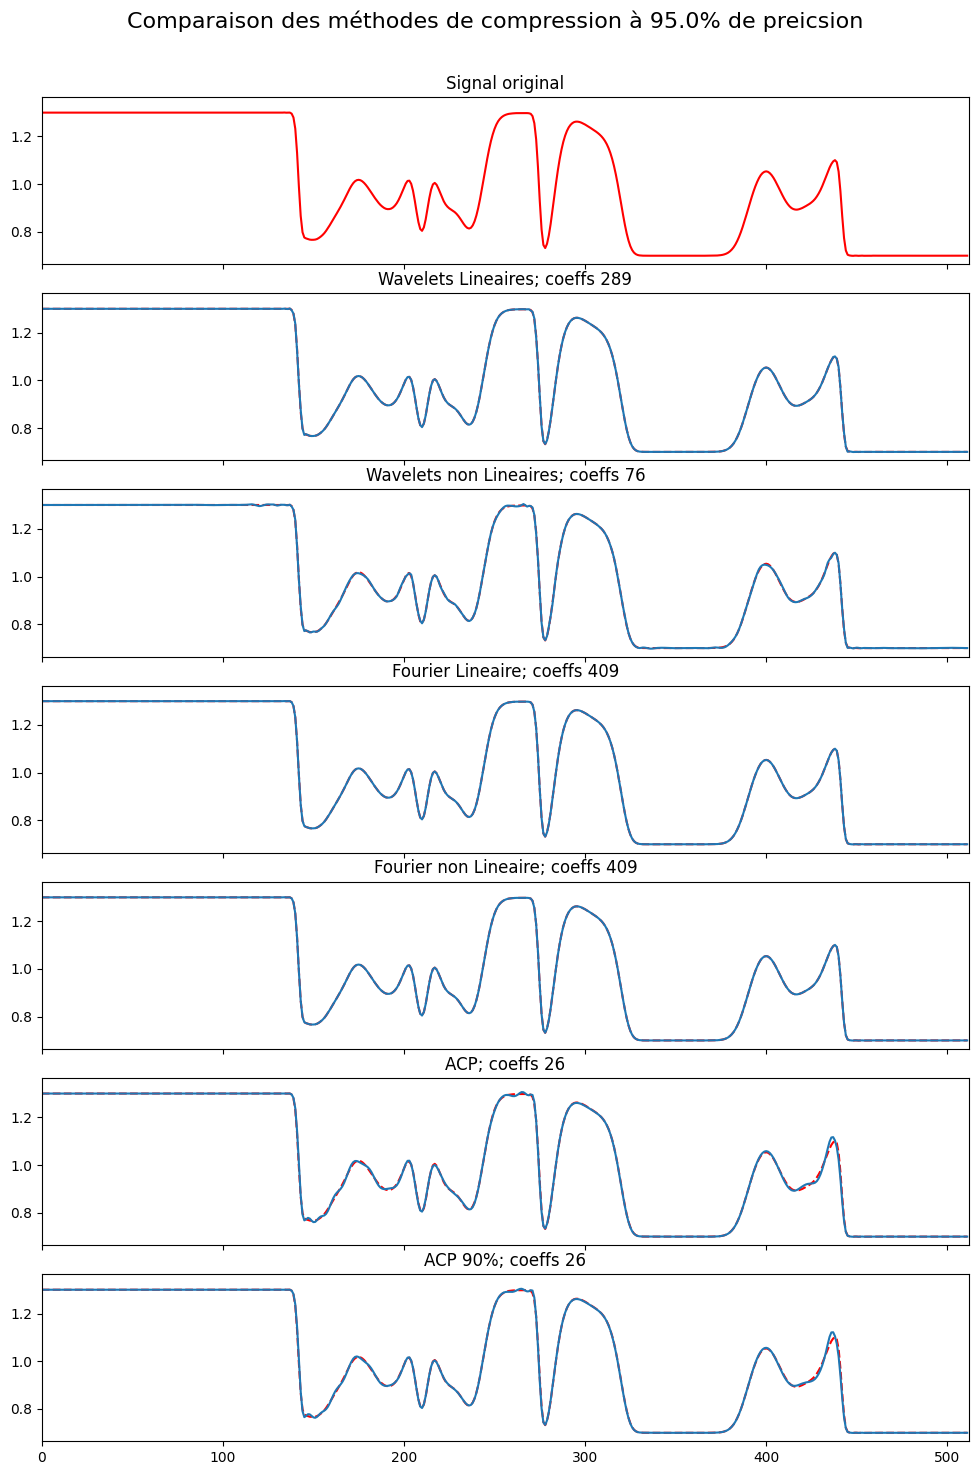

In [29]:
fig, ax = plt.subplots(len(methods)+1, 1, figsize=(10, 15), sharex=True)
y_inf,y_supp = 0.95*np.min(signals[t]),1.05*np.max(signals[t])

fig.suptitle("Comparaison des méthodes de compression à "+str((1-T)*100)+"% de preicsion", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
ax[0].plot(signals[t], color="red")
ax[0].set_xlim(0, signals[t].shape[0])
ax[0].set_title(f'Signal original')
ax[0].set_ylim(y_inf,y_supp)

for i in range(len(methods)):
    ti = str(methods[i]) + "; coeffs " + str(n[i])
    ax[i+1].plot(signals[t], color="red", linestyle="--")
    ax[i+1].plot(si[i,:])
    ax[i+1].set_ylim(y_inf,y_supp)
    ax[i+1].set_title(ti)

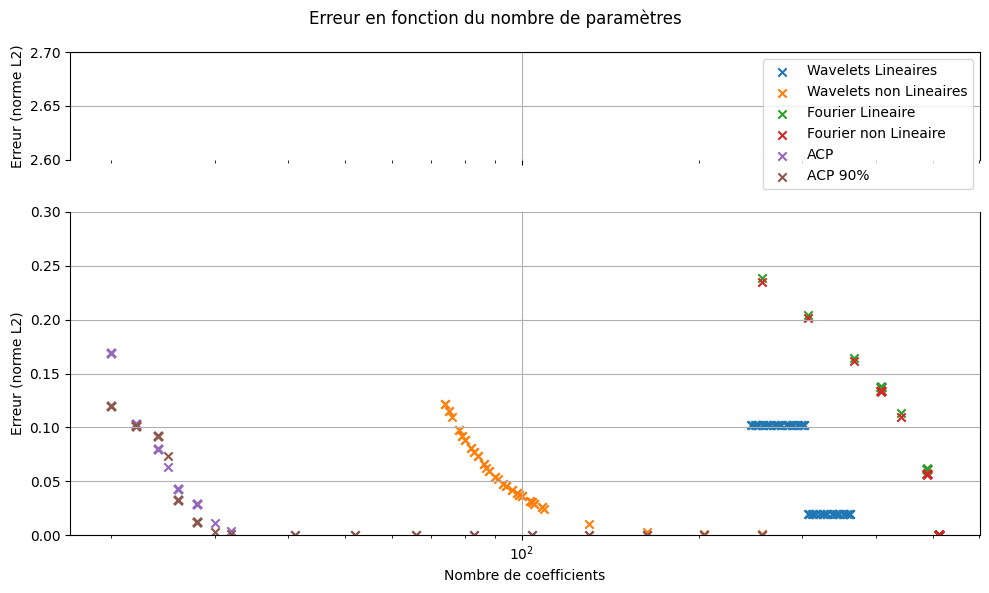

In [30]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(10, 6),
    gridspec_kw={'height_ratios': [1, 3]}
)

for j in range(len(methods)):
    # ax1.plot(errors[j, :, 0], errors[j, :, 1], label=methods[j])
    # ax2.plot(errors[j, :, 0], errors[j, :, 1], label=methods[j])
    ax1.scatter(errors[j, :, 0], errors[j, :, 1],marker='x', label=methods[j])
    ax2.scatter(errors[j, :, 0], errors[j, :, 1],marker='x', label=methods[j])

# ------ Limites des axes pour faire une cassure ------ #
ax1.set_ylim(2.6, 2.7)   # zone haute
ax2.set_ylim(0, 0.3)     # zone basse

ax1.set_xscale('log')
ax2.set_xscale('log')

# ------ Style ------- # 
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False)
ax2.xaxis.tick_bottom()

# ------ Lables ------ #
ax2.set_xlabel("Nombre de coefficients")
ax1.set_ylabel("Erreur (norme L2)")
ax2.set_ylabel("Erreur (norme L2)")

ax1.legend()
ax1.grid()
ax2.grid()

plt.suptitle("Erreur en fonction du nombre de paramètres")
plt.tight_layout()
plt.show()

---
## ECHANTILLONNAGE FIXE : erreur vs nombre de coefficients

In [31]:
n_fixed = 45 

In [32]:
N = signals.shape[1]
coeff_values = np.unique(np.round(np.geomspace(1, N // 2, num=40)).astype(int))

errors_fixed = np.zeros((len(methods), len(coeff_values)))
si_fixed = np.zeros((len(methods), N))

for ci, n_coeff in enumerate(coeff_values):
    si_fixed[0, :] = wavelet_lineaire(signals[t], n_coeff, wavelet)
    si_fixed[1, :] = wavelet_non_lineaire(signals[t], n_coeff, wavelet)
    si_fixed[2, :] = fourier_lineaire(signals[t], n_coeff)
    si_fixed[3, :] = fourier_non_lineaire(signals[t], n_coeff)
    si_fixed[4, :] = acp_non_lineaire(base_acp, signals[t], n_coeff)
    si_fixed[5, :] = acp_non_lineaire(sbase_acp, signals[t], n_coeff)

    for j in range(len(methods)):
        errors_fixed[j, ci] = np.linalg.norm(si_fixed[j] - signals[t])

In [33]:
for j in range(len(methods)):
    n_idx = np.argmin(np.abs(coeff_values - n_fixed))
    si_fixed[j, :] = [
        wavelet_lineaire,
        wavelet_non_lineaire,
        fourier_lineaire,
        fourier_non_lineaire,
        lambda s, n, *_: acp_non_lineaire(base_acp, s, n),
        lambda s, n, *_: acp_non_lineaire(sbase_acp, s, n),
    ][j](signals[t], coeff_values[n_idx], wavelet) if j < 2 else [
        fourier_lineaire,
        fourier_non_lineaire,
        lambda s, n: acp_non_lineaire(base_acp, s, n),
        lambda s, n: acp_non_lineaire(sbase_acp, s, n),
    ][j - 2](signals[t], coeff_values[n_idx])

In [34]:
N = signals.shape[1]
coeff_values = np.unique(np.round(np.geomspace(1, N // 2, num=40)).astype(int))
errors_fixed = np.zeros((len(methods), len(coeff_values)))

def reconstruct(j, sig, n_coeff):
    """Applique la méthode j avec n_coeff coefficients."""
    if j == 0: return wavelet_lineaire(sig, n_coeff, wavelet)
    if j == 1: return wavelet_non_lineaire(sig, n_coeff, wavelet)
    if j == 2: return fourier_lineaire(sig, n_coeff)
    if j == 3: return fourier_non_lineaire(sig, n_coeff)
    if j == 4: return acp_non_lineaire(base_acp, sig, n_coeff)
    if j == 5: return acp_non_lineaire(sbase_acp, sig, n_coeff)

for ci, n_coeff in enumerate(coeff_values):
    for j in range(len(methods)):
        sig_rec = reconstruct(j, signals[t], n_coeff)
        errors_fixed[j, ci] = np.linalg.norm(sig_rec - signals[t])

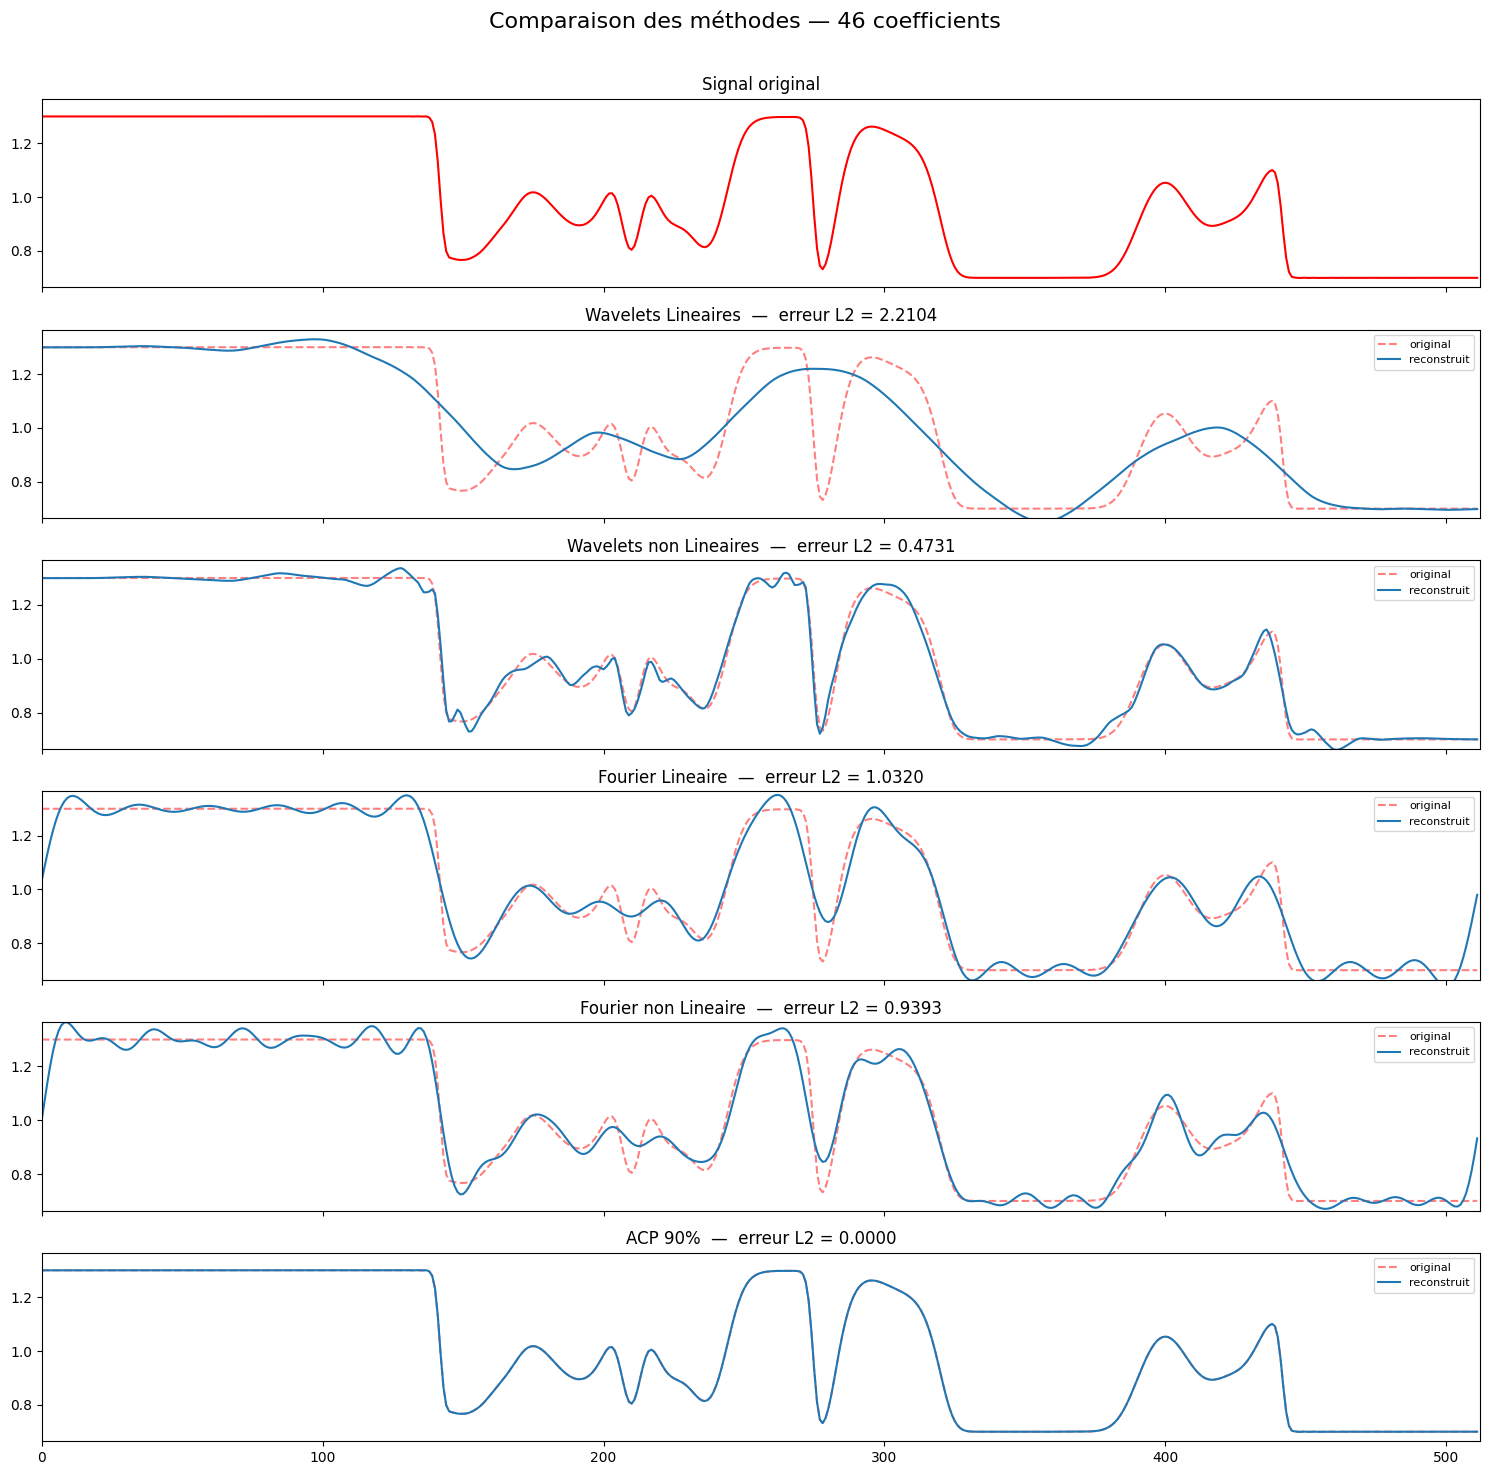

In [40]:
methods = [
    "Wavelets Lineaires",
    "Wavelets non Lineaires",
    "Fourier Lineaire",
    "Fourier non Lineaire",
    # "ACP",
    "ACP " + str(pACP) + "%"
]

n_idx   = np.argmin(np.abs(coeff_values - n_fixed))
n_actual = coeff_values[n_idx]

y_inf  = 0.95 * np.min(signals[t])
y_supp = 1.05 * np.max(signals[t])

fig, ax = plt.subplots(len(methods) + 1, 1, figsize=(15, 15), sharex=True)
fig.suptitle(f"Comparaison des méthodes — {n_actual} coefficients", fontsize=16)

ax[0].plot(signals[t], color="red")
ax[0].set_title("Signal original")
ax[0].set_ylim(y_inf, y_supp)
ax[0].set_xlim(0, N)

for j in range(len(methods)):
    sig_rec = reconstruct(j, signals[t], n_actual)
    err     = np.linalg.norm(sig_rec - signals[t])
    ax[j+1].plot(signals[t], color="red", linestyle="--", alpha=0.5, label="original")
    ax[j+1].plot(sig_rec, label="reconstruit")
    ax[j+1].set_ylim(y_inf, y_supp)
    ax[j+1].set_title(f"{methods[j]}  —  erreur L2 = {err:.4f}")
    ax[j+1].legend(loc="upper right", fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("img/signal/1D_Comparaison.png", dpi=300)
plt.show()

/tmp/ipykernel_584872/1675346560.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(x_min, x_max)


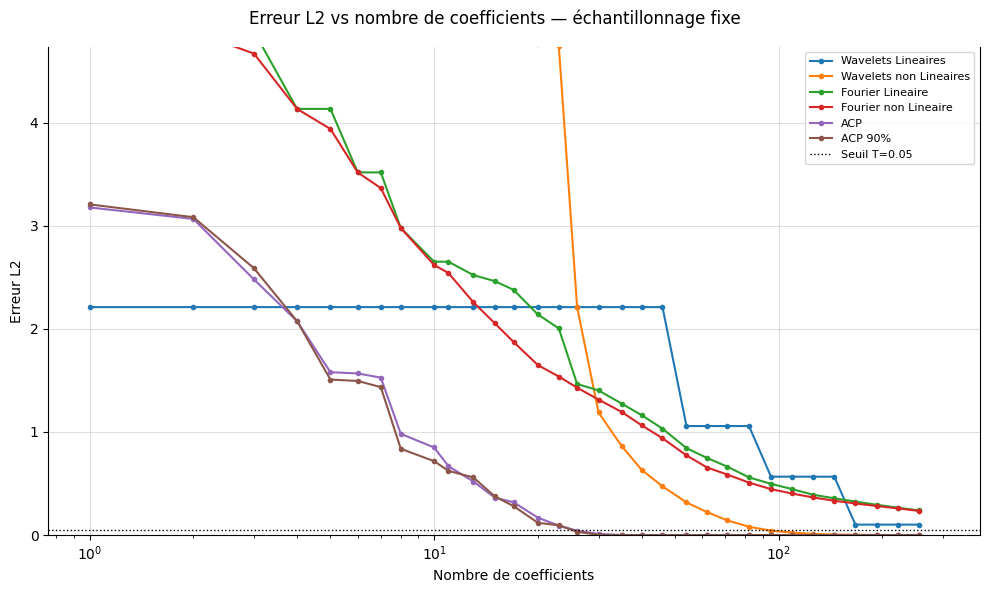

In [36]:
fig, ax2 = plt.subplots(
    1, 1, sharex=True, figsize=(10, 6),
)

for j in range(len(methods)):
    ax2.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])

ax2.axhline(y=T, color='black', linestyle=':', linewidth=1, label=f"Seuil T={T}")

ax2.set_ylim(0, np.percentile(errors_fixed, 90))

ax2.spines['top'].set_visible(False)
ax2.xaxis.tick_bottom()

ax2.set_xscale('log')  

x_min = 0
x_max = coeff_values[-1] * 1.5 
ax2.set_xlim(x_min, x_max)      
ax2.legend(fontsize=8, loc="upper right")
ax2.set_xlabel("Nombre de coefficients")
ax2.set_ylabel("Erreur L2")
ax2.grid(True, alpha=0.4)

plt.suptitle("Erreur L2 vs nombre de coefficients — échantillonnage fixe")
plt.tight_layout()
plt.show()

/tmp/ipykernel_584872/3360827349.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(x_min, x_max)
/tmp/ipykernel_584872/3360827349.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(x_min, x_max)


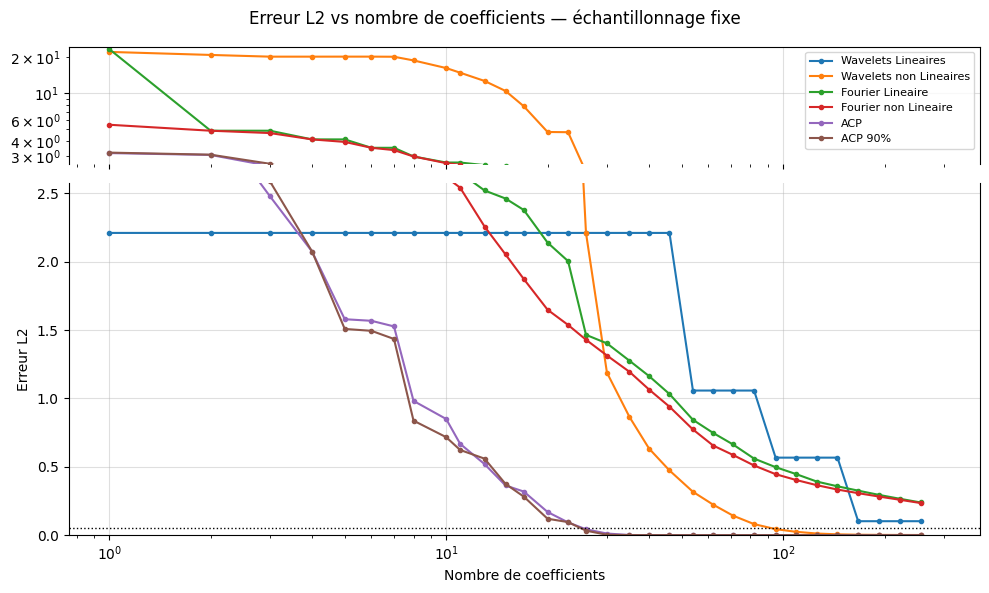

In [37]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6),
    gridspec_kw={'height_ratios': [1, 3]}
)

for j in range(len(methods)):
    ax1.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])
    ax2.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])

# Seuil T pour référence
ax2.axhline(y=T, color='black', linestyle=':', linewidth=1, label=f"Seuil T={T}")

# Axe brisé
ax1.set_ylim(np.percentile(errors_fixed, 80), errors_fixed.max() * 1.05)
ax2.set_ylim(0, np.percentile(errors_fixed, 80))

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labelbottom=False)
ax2.xaxis.tick_bottom()

# --- Fix : échelle log + xlim identique et explicite sur les 2 axes ---
ax2.set_xscale('log')  # suffit grâce à sharex, mais on fixe xlim manuellement
ax1.set_yscale('log')
x_min = 0  
x_max = coeff_values[-1] * 1.5  
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

ax2.set_xlabel("Nombre de coefficients")
ax2.set_ylabel("Erreur L2")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.4)
ax2.grid(True, alpha=0.4)

plt.suptitle("Erreur L2 vs nombre de coefficients — échantillonnage fixe")
plt.tight_layout()
plt.show()